In [1]:
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)


import os

print(os.listdir("../input"))




['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']


In [2]:
import cv2




In [3]:
from PIL import Image
from matplotlib import pyplot as plt




In [4]:
import torch

# Ensure reproducibility
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False




In [5]:
DATA_DIR = "../input/"
TRAIN_DIR = DATA_DIR + "train/train/"
NAMES_DIR = DATA_DIR + "train.csv"




In [6]:
TEST_DIR = "../input/test/test/"  # path that contains the test images (may include a subfolder)




In [7]:
os.listdir(TEST_DIR)




['76bad42ebc1ed65f7f50c06fd17849db.jpg',
 'f620bd2745d51c25cd05eca4f7c4da94.jpg',
 '0e47e71ea2829d6d88944482ada145a5.jpg',
 'd66598ea219072e9c0b98e1a162cc8f6.jpg',
 '3288a35f07e97293155203bec36c0a8d.jpg',
 '05e406596f183ddc1d771de2c7af6eb1.jpg',
 '454f59bef7140259bbb9875a836355cd.jpg',
 '589de864efdaa264d19112d946d17826.jpg',
 'b5f7b64eb412f94d352ad01e6e6106d7.jpg',
 '890ae48097378d600cfbc0b93566c155.jpg',
 '9d052bee693b53a48fa3503f1eafbea8.jpg',
 '2c7e6f5d7b6165001bbb9523d2efd4ee.jpg',
 '106b2f33541f5b23cb4805cdffc87db6.jpg',
 '712ed765f98a19b8cd21a5a8c96ff4a5.jpg',
 'cebe5aeeb39cdc7349e4783353e6254f.jpg',
 'df1e111ef8ec047a456ba11ba7ef96f0.jpg',
 '73ca87e899048fb0f1a020361af74eac.jpg',
 '4e98c9d667be711ac1b593e79906d2e7.jpg',
 'f852db0e5fcded7e80be3a8b3993a66d.jpg',
 '8886a5647fee68f9ef200fa2bd7b9c22.jpg',
 '74f611a1f3d41313fe35ec75c50e3c15.jpg',
 '2246209a6d93a68be1dbf1fcd66e78ab.jpg',
 'a543d2de2b076d4ddc5406583221ea8d.jpg',
 'cc1a534bf86d2adbb449091229fa2148.jpg',
 '67d8fe28186d32

In [8]:
train_names = pd.read_csv(NAMES_DIR)
train_names.shape




(14175, 2)

In [9]:
len(os.listdir(TRAIN_DIR))




14176

In [10]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
import torchvision.transforms as transforms




0


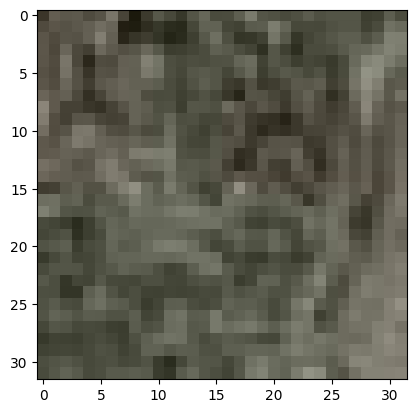

In [11]:
def show_image(index):
    image = Image.open(TRAIN_DIR + str(train_names["id"][index]))
    plt.imshow(image)
    print(train_names["has_cactus"][index])


show_image(20)




In [12]:
class HasCactusDataset(Dataset):

    def __init__(self, csv_file, root_dir, transform=None):
        self.img_names = pd.read_csv(csv_file)
        self.root_dir = root_dir
        # add a tiny augmentation; core architecture unchanged
        self.transform = (
            transform
            if transform is not None
            else transforms.Compose(
                [transforms.RandomHorizontalFlip(), transforms.ToTensor()]
            )
        )

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.img_names.iloc[idx, 0])
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            img_cv = cv2.imread(img_path)
            if img_cv is None:
                raise FileNotFoundError(f"Image not found or unreadable: {img_path}")
            image = Image.fromarray(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
        image = self.transform(image)  # shape C x H x W, float in [0,1]
        has_cactus = torch.tensor(self.img_names.iloc[idx, 1], dtype=torch.float32)
        return image, has_cactus




In [13]:
hasCactusDataset = HasCactusDataset(
    csv_file=DATA_DIR + "train.csv",
    root_dir=TRAIN_DIR,
    transform=transforms.Compose(
        [transforms.RandomHorizontalFlip(), transforms.ToTensor()]
    ),
)




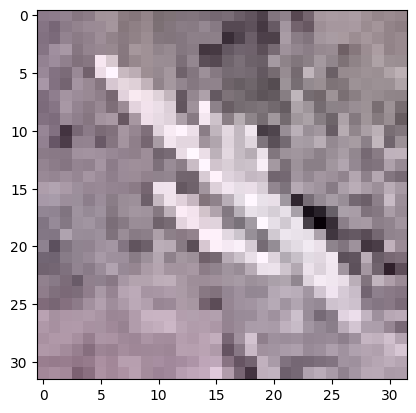

In [14]:
plt.imshow(hasCactusDataset[19][0].permute(1, 2, 0).numpy())




In [15]:
dataloader = DataLoader(hasCactusDataset, batch_size=128, shuffle=True)




In [16]:
import torch.nn as nn
import torch.nn.functional as F




In [17]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 10, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(10, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv3 = nn.Conv2d(16, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x


net = Net()




In [18]:
import torch.optim as optim

criterion = nn.BCELoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)  # Adam converges faster than SGD




In [19]:
for epoch in range(50):  # increased epochs for better learning
    running_loss = 0.0
    print(f"epoch {epoch} started...")
    for i, (images, labels) in enumerate(dataloader):
        optimizer.zero_grad()
        inputs = images.float()
        labels = labels.view(-1, 1).float()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"epoch {epoch} complete, loss: {running_loss/len(dataloader):.4f}")

print("finished Training...")




epoch 0 started...
epoch 0 complete, loss: 0.4199
epoch 1 started...
epoch 1 complete, loss: 0.1654
epoch 2 started...
epoch 2 complete, loss: 0.1398
epoch 3 started...
epoch 3 complete, loss: 0.1285
epoch 4 started...
epoch 4 complete, loss: 0.1207
epoch 5 started...
epoch 5 complete, loss: 0.1084
epoch 6 started...
epoch 6 complete, loss: 0.1070
epoch 7 started...
epoch 7 complete, loss: 0.1047
epoch 8 started...
epoch 8 complete, loss: 0.0970
epoch 9 started...
epoch 9 complete, loss: 0.0961
epoch 10 started...
epoch 10 complete, loss: 0.0767
epoch 11 started...
epoch 11 complete, loss: 0.0735
epoch 12 started...
epoch 12 complete, loss: 0.0696
epoch 13 started...
epoch 13 complete, loss: 0.0673
epoch 14 started...
epoch 14 complete, loss: 0.0688
epoch 15 started...
epoch 15 complete, loss: 0.0584
epoch 16 started...
epoch 16 complete, loss: 0.0536
epoch 17 started...
epoch 17 complete, loss: 0.0498
epoch 18 started...
epoch 18 complete, loss: 0.0501
epoch 19 started...
epoch 19 com

In [20]:
data = next(iter(dataloader))




In [21]:
os.listdir(TEST_DIR)




['76bad42ebc1ed65f7f50c06fd17849db.jpg',
 'f620bd2745d51c25cd05eca4f7c4da94.jpg',
 '0e47e71ea2829d6d88944482ada145a5.jpg',
 'd66598ea219072e9c0b98e1a162cc8f6.jpg',
 '3288a35f07e97293155203bec36c0a8d.jpg',
 '05e406596f183ddc1d771de2c7af6eb1.jpg',
 '454f59bef7140259bbb9875a836355cd.jpg',
 '589de864efdaa264d19112d946d17826.jpg',
 'b5f7b64eb412f94d352ad01e6e6106d7.jpg',
 '890ae48097378d600cfbc0b93566c155.jpg',
 '9d052bee693b53a48fa3503f1eafbea8.jpg',
 '2c7e6f5d7b6165001bbb9523d2efd4ee.jpg',
 '106b2f33541f5b23cb4805cdffc87db6.jpg',
 '712ed765f98a19b8cd21a5a8c96ff4a5.jpg',
 'cebe5aeeb39cdc7349e4783353e6254f.jpg',
 'df1e111ef8ec047a456ba11ba7ef96f0.jpg',
 '73ca87e899048fb0f1a020361af74eac.jpg',
 '4e98c9d667be711ac1b593e79906d2e7.jpg',
 'f852db0e5fcded7e80be3a8b3993a66d.jpg',
 '8886a5647fee68f9ef200fa2bd7b9c22.jpg',
 '74f611a1f3d41313fe35ec75c50e3c15.jpg',
 '2246209a6d93a68be1dbf1fcd66e78ab.jpg',
 'a543d2de2b076d4ddc5406583221ea8d.jpg',
 'cc1a534bf86d2adbb449091229fa2148.jpg',
 '67d8fe28186d32

In [22]:
class TestSet(Dataset):

    def __init__(self, root_dir, transform=None):
        # keep only files (skip possible sub‑folders)
        self.img_names = sorted(
            [
                f
                for f in os.listdir(root_dir)
                if os.path.isfile(os.path.join(root_dir, f))
            ]
        )
        self.root_dir = root_dir
        self.transform = transform if transform is not None else transforms.ToTensor()

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.root_dir, img_name)
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            img_cv = cv2.imread(img_path)
            if img_cv is None:
                raise FileNotFoundError(
                    f"Test image not found or unreadable: {img_path}"
                )
            image = Image.fromarray(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
        image = self.transform(image)  # C x H x W
        return image, img_name




In [23]:
testSet = TestSet(
    root_dir=TEST_DIR, transform=transforms.Compose([transforms.ToTensor()])
)




In [24]:
testloader = DataLoader(
    testSet, batch_size=1, shuffle=False
)  # shuffle=False to keep order




In [25]:
tstdata = next(iter(testloader))




In [26]:
tstdata[0].shape




torch.Size([1, 3, 32, 32])

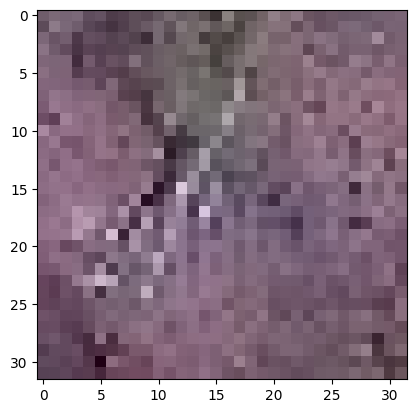

In [27]:
plt.imshow(tstdata[0][0].permute(1, 2, 0).numpy())




In [28]:
tst_outputs = []
tst_names = []
net.eval()
with torch.no_grad():
    for image, name in testloader:
        inputs = image.float()
        output = net(inputs).item()
        tst_outputs.append(output)
        tst_names.append(name[0])
print(f"Collected predictions for {len(tst_names)} test images.")




Collected predictions for 3325 test images.


In [29]:
len(tst_outputs)




3325

In [30]:
tst_outputs




[1.0,
 1.0,
 1.0,
 0.0007858860772103071,
 0.0012107937363907695,
 1.0,
 0.9999876022338867,
 1.0,
 0.9997223019599915,
 0.9999995231628418,
 1.0,
 0.000925825908780098,
 1.0,
 1.0,
 0.001291672233492136,
 0.005330071318894625,
 0.9999998807907104,
 0.9937711358070374,
 1.0,
 1.0,
 1.0,
 0.999998927116394,
 1.0,
 1.0,
 0.0006487496430054307,
 0.0009910945082083344,
 0.9999498128890991,
 1.0,
 0.999956488609314,
 1.0,
 0.9817447066307068,
 1.0,
 0.005727623123675585,
 1.0,
 0.9999620914459229,
 0.0006771148182451725,
 1.0,
 1.0,
 1.0,
 0.9998838901519775,
 0.00020604768360499293,
 0.999996542930603,
 1.0,
 0.9997854828834534,
 0.0006044668261893094,
 1.0,
 0.9999998807907104,
 1.0,
 0.0006638352642767131,
 1.0,
 1.0,
 0.9999983310699463,
 0.9978959560394287,
 0.9999977350234985,
 0.9997501969337463,
 0.7064172029495239,
 1.0,
 0.009206033311784267,
 0.004816221073269844,
 0.0002379084617132321,
 0.9999990463256836,
 1.0,
 1.0,
 0.9999996423721313,
 1.0,
 1.0,
 1.0,
 0.9999998807907104,


In [31]:
len(tst_names)




3325

In [32]:
my_submission = pd.DataFrame({"id": tst_names, "has_cactus": tst_outputs})
my_submission.to_csv("submission.csv", index=False)
print("Submission saved to submission.csv with", len(my_submission), "rows.")




Submission saved to submission.csv with 3325 rows.


In [33]:
tst_names

['002930423b9840e67e5a54afd4768a1e.jpg',
 '00351838ebf6dff6e53056e00a1e307c.jpg',
 '003ec9bcef67171ba49fe4c3b7c80aec.jpg',
 '0051207eb794887c619341090de84b50.jpg',
 '0057728c8522c4881af60c3105b6492e.jpg',
 '008fa43d2e3c2354fc174d22a12a2055.jpg',
 '009350e896ad5c23456ce7697d4de276.jpg',
 '009eead3ac74832bc9822f3342d97fce.jpg',
 '00ba3da3fe6d600703e28dece68fbb12.jpg',
 '00be32b57f411d75293bb7234aabeb58.jpg',
 '00c87df5297724cce38803472916585f.jpg',
 '00d1bda309e7f661f68711a53bc727ea.jpg',
 '0100391ae925aeec1299cb26288b4a0c.jpg',
 '010b26d37323da77a7b6884bf9177a2f.jpg',
 '011429a2829fb9beb304a12083aa0e12.jpg',
 '012b44ac8e076a98c077b30067896e6b.jpg',
 '0148bb4a295cf49c0169d69a4a63df7e.jpg',
 '0155ad044d20f08e1c9bb25932ae6a90.jpg',
 '01745568411334c1bafec6ac6e8d1a68.jpg',
 '01a548f7498899fb08a70aac664a8357.jpg',
 '01b824b1cd6e5d1cd9ca55ee5e48d18c.jpg',
 '01c2d620db0156458bcf7bf0d56755e2.jpg',
 '01c31f7ac52cde7cb92c711368f9362f.jpg',
 '01c3795ea42f56b79358c70e316a7882.jpg',
 '01c97273462a2f